# 花卉数据集图像分类（CNN，PyTorch）

本 notebook 读取 `DataSets/flower_data` 下的花卉图片数据，完成：

- 数据读取与预处理（训练/验证/测试划分、数据增强、归一化）
- 搭建基于卷积神经网络（CNN）的分类模型并训练
- 输出训练结果并可视化（Loss/Accuracy 曲线、预测效果图）

> 数据集目录结构（`ImageFolder` 约定）：
>
> ```
> DataSets/flower_data/
>   daisy/
>   dandelion/
>   roses/
>   sunflowers/
>   tulips/
> ```

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 让实验可复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.8.0+cu129


## 1. 读取数据集与数据预处理

我们使用 `torchvision.datasets.ImageFolder` 直接从文件夹读取图片。

- **数据增强（train）**：随机裁剪/翻转/轻微颜色抖动，提升泛化
- **验证/测试（val/test）**：只做 Resize + CenterCrop，保持评估稳定
- **归一化**：使用 ImageNet 的 mean/std（通用且常用）

同时把全量数据集按比例划分为：train/val/test。

In [ ]:
# 导入必要库（根据代码推断，实际运行需确保导入）
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 固定随机种子，保证实验可复现
SEED = 42
torch.manual_seed(SEED)

# ===================== 1. 数据集路径配置 =====================
# 定义数据集根目录
DATA_DIR = Path("../DataSets/flower_data")
# 断言检查：确保数据目录存在，不存在则直接报错提示路径
assert DATA_DIR.exists(), f"找不到数据目录: {DATA_DIR.resolve()}"

# ===================== 2. 训练超参数配置 =====================
# 输入图像尺寸（模型接收的图片大小）
IMG_SIZE = 224
# 批次大小：每次训练输入的图片数量
BATCH_SIZE = 32
# 数据加载线程数：Windows 系统设置为 0 稳定性更好
NUM_WORKERS = 0  

# ===================== 3. 图像归一化参数 =====================
# ImageNet 数据集的均值和标准差，用于迁移学习时统一数据分布
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# ===================== 4. 图像预处理/数据增强 =====================
# 训练集预处理：包含数据增强，提升模型泛化能力
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # 先放大尺寸，为裁剪做准备
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),  # 随机裁剪到目标尺寸
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转，概率 50%
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),  # 随机调整亮度/对比度/饱和度/色调
    transforms.ToTensor(),  # 转换为 PyTorch 张量
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # 归一化
])

# 验证/测试集预处理：仅做基础处理，不使用数据增强
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # 统一尺寸
    transforms.CenterCrop(IMG_SIZE),  # 中心裁剪到目标尺寸
    transforms.ToTensor(),  # 转换为张量
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # 归一化
])

# ===================== 5. 构建基础数据集 =====================
# 先用无增强的 transform 创建基础数据集，仅用于读取类别和划分数据集
base_ds = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)
# 获取数据集的类别名称列表
class_names = base_ds.classes
# 获取类别总数
num_classes = len(class_names)

# 打印数据集基础信息
print("num_classes:", num_classes)
print("classes:", class_names)
print("total images:", len(base_ds))

# ===================== 6. 按比例划分数据集 =====================
# 设定训练集、验证集、测试集比例：7:1.5:1.5
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
# 总样本数量
n_total = len(base_ds)
# 计算各子集样本数量
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)
n_test = n_total - n_train - n_val

# 随机划分数据集，固定随机种子保证划分结果一致
train_ds, val_ds, test_ds = random_split(
    base_ds,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

# ===================== 7. 为子集替换预处理方式 =====================
# 核心：训练集使用带增强的预处理，验证/测试集保持无增强
train_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_tfms)
val_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)
test_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)

# ===================== 8. 创建数据加载器 =====================
# 训练加载器：打乱顺序（shuffle=True）
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
# 验证/测试加载器：不打乱顺序
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 打印划分后各子集的大小
print("split sizes:", len(train_ds), len(val_ds), len(test_ds))

num_classes: 5
classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
total images: 3670
split sizes: 2569 550 551


## 2. 可视化：看几张增强后的训练样本

为了确认数据读取与增强没问题，我们从 `train_loader` 抽取一个 batch，把归一化后的张量反归一化并显示。

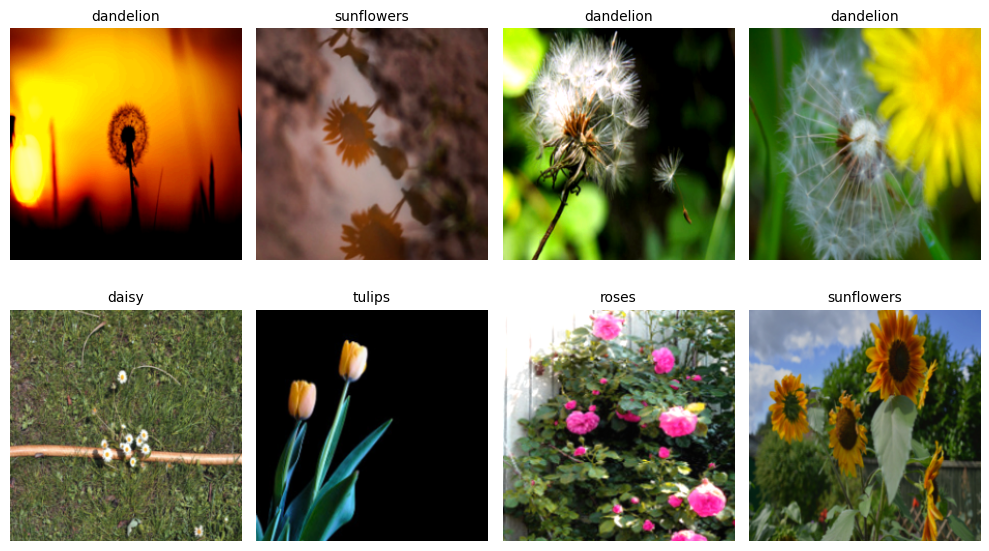

In [3]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    x = img_tensor.detach().cpu() * std + mean
    return x.clamp(0, 1)

batch_imgs, batch_labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
show_n = min(8, batch_imgs.size(0))
for i in range(show_n):
    plt.subplot(2, 4, i + 1)
    img = denormalize(batch_imgs[i])
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[int(batch_labels[i])], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. 搭建 CNN 模型

这里实现一个轻量 CNN：多层卷积 + BatchNorm + ReLU + 池化，最后用全局平均池化（`AdaptiveAvgPool2d`）接全连接分类。

如果你后续希望更高精度，也可以替换成 `torchvision.models` 的预训练网络（如 ResNet18），但本任务先用“从零搭建”的 CNN 更直观。

In [ ]:
# 定义简单的卷积神经网络模型，继承自nn.Module（PyTorch所有模型的基类）
class SimpleCNN(nn.Module):
    # 初始化函数，num_classes为分类的类别数量
    def __init__(self, num_classes: int):
        # 调用父类nn.Module的初始化方法
        super().__init__()
        
        # 特征提取模块：由卷积、批归一化、激活、池化层组成，用于提取图像特征
        self.features = nn.Sequential(
            # 第一层卷积：输入通道3(RGB图像)，输出通道32，3x3卷积核，padding=1保证尺寸不变
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # 对32个通道做批归一化，加速训练、防止过拟合
            nn.ReLU(inplace=True),  # ReLU激活函数，inplace=True节省内存
            nn.MaxPool2d(2),  # 最大池化，池化核2x2，特征图尺寸缩小一半

            # 第二层卷积：输入通道32，输出通道64，其余参数同上
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 第三层卷积：输入通道64，输出通道128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 第四层卷积：输入通道128，输出通道256（通道数随网络加深逐步增加）
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        # 自适应平均池化：无论输入特征图尺寸是多少，都输出 1x1 的特征图
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 分类器模块：将提取的特征映射为最终的分类结果
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 展平操作：将 1x1x256 的特征展平为 256 维向量
            nn.Dropout(p=0.3),  # Dropout随机失活30%神经元，防止模型过拟合
            nn.Linear(256, num_classes),  # 全连接层：输入256维特征，输出num_classes个类别概率
        )

    # 前向传播函数：定义数据在模型中的流动路径
    def forward(self, x):
        x = self.features(x)    # 第一步：通过特征提取层提取图像特征
        x = self.pool(x)       # 第二步：自适应池化，固定特征维度
        x = self.classifier(x) # 第三步：通过分类器输出分类结果
        return x

# 实例化模型，并将模型移动到指定设备（CPU/GPU）
model = SimpleCNN(num_classes=num_classes).to(device)
# 打印模型整体结构
print(model)

# 计算模型可训练参数量
# p.numel()：计算单个参数张量的元素总数；只统计需要梯度更新的参数
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# 打印参数量，单位转换为百万（M），保留两位小数
print(f"trainable params: {num_params/1e6:.2f}M")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

## 4. 训练与验证

训练时记录每个 epoch 的：

- **train loss / train acc**
- **val loss / val acc**

并在验证集上保存表现最好的模型权重（以 `val acc` 为准）。

In [6]:
# 导入数据类装饰器，用于简洁定义数据存储类
from dataclasses import dataclass
# 导入PyTorch核心库
import torch
# 导入神经网络模块
import torch.nn as nn

# 定义一个数据类，用于存储每个epoch的损失值和准确率
@dataclass
class EpochStats:
    loss: float  # 损失值
    acc: float   # 准确率

# 从模型输出的logits计算准确率
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    # 获取预测类别：在维度1上取最大值的索引（对应分类预测结果）
    preds = logits.argmax(dim=1)
    # 计算预测正确的样本比例，转换为float并返回数值
    return (preds == y).float().mean().item()

# 禁用梯度计算，提升评估速度、节省显存
@torch.no_grad()
# 模型评估函数：输入模型、数据加载器、损失函数，返回评估指标
def evaluate(model, loader, criterion):
    # 将模型设置为评估模式（关闭dropout、batchnorm等训练特有的层）
    model.eval()
    # 初始化累计损失
    total_loss = 0.0
    # 初始化预测正确的样本总数
    total_correct = 0
    # 初始化总样本数
    total = 0

    # 遍历验证集的每个批次
    for x, y in loader:
        # 将数据和标签移动到指定设备（CPU/GPU）
        x, y = x.to(device), y.to(device)
        # 模型前向传播，得到输出logits
        logits = model(x)
        # 计算当前批次的损失
        loss = criterion(logits, y)

        # 累加损失：loss.item()是标量，乘以批次大小，保证加权平均正确
        total_loss += loss.item() * x.size(0)
        # 累加当前批次预测正确的样本数量
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        # 累加总样本数
        total += x.size(0)

    # 计算平均损失和平均准确率，封装为EpochStats返回
    return EpochStats(loss=total_loss / total, acc=total_correct / total)

# 模型训练主函数
def train(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    # 定义分类任务的损失函数：交叉熵损失
    criterion = nn.CrossEntropyLoss()
    # 定义优化器：Adam优化器，传入模型参数、学习率、权重衰减（L2正则）
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # 定义字典，用于记录训练过程中的所有指标
    history = {
        "train_loss": [],  # 训练集损失
        "train_acc": [],   # 训练集准确率
        "val_loss": [],    # 验证集损失
        "val_acc": [],     # 验证集准确率
    }

    # 初始化最佳验证集准确率（初始值设为-1，保证第一个epoch一定更新）
    best_val_acc = -1.0
    # 存储表现最佳的模型参数
    best_state = None

    # 开始循环训练，遍历每个epoch
    for epoch in range(1, epochs + 1):
        # 将模型设置为训练模式
        model.train()
        # 初始化训练批次累计损失
        running_loss = 0.0
        # 初始化训练批次正确预测数
        running_correct = 0
        # 初始化训练批次总样本数
        running_total = 0

        # 遍历训练集的每个批次
        for x, y in train_loader:
            # 数据和标签移动到指定设备
            x, y = x.to(device), y.to(device)

            # 清空上一步的梯度，防止梯度累加
            optimizer.zero_grad(set_to_none=True)
            # 模型前向传播
            logits = model(x)
            # 计算损失
            loss = criterion(logits, y)
            # 反向传播：计算梯度
            loss.backward()
            # 优化器更新参数
            optimizer.step()

            # 累加当前批次损失（加权）
            running_loss += loss.item() * x.size(0)
            # 累加当前批次正确预测数
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            # 累加总样本数
            running_total += x.size(0)

        # 计算当前epoch的训练集平均损失
        train_loss = running_loss / running_total
        # 计算当前epoch的训练集平均准确率
        train_acc = running_correct / running_total

        # 调用评估函数，得到验证集指标
        val_stats = evaluate(model, val_loader, criterion)

        # 将当前epoch指标存入历史记录
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_stats.loss)
        history["val_acc"].append(val_stats.acc)

        # 如果当前验证集准确率更高，更新最佳模型
        if val_stats.acc > best_val_acc:
            best_val_acc = val_stats.acc
            # 深拷贝模型参数，脱离计算图，保存到CPU
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # 打印当前epoch的训练和验证指标
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_stats.loss:.4f} acc {val_stats.acc:.4f}"
        )

    # 训练结束后，加载最优的模型参数
    if best_state is not None:
        model.load_state_dict(best_state)

    # 返回训练全过程的指标记录
    return history

# 设置训练总轮数
EPOCHS = 100
# 设置学习率
LR = 1e-3

# 启动训练，传入模型、训练集、验证集、超参数，接收训练历史
history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 01/100 | train loss 1.1492 acc 0.5391 | val loss 1.0660 acc 0.5982
Epoch 02/100 | train loss 1.0572 acc 0.5815 | val loss 1.0321 acc 0.6473
Epoch 03/100 | train loss 0.9873 acc 0.6154 | val loss 0.9602 acc 0.6491
Epoch 04/100 | train loss 0.9619 acc 0.6283 | val loss 0.8798 acc 0.6782
Epoch 05/100 | train loss 0.9112 acc 0.6540 | val loss 1.0566 acc 0.6527
Epoch 06/100 | train loss 0.8824 acc 0.6703 | val loss 0.9310 acc 0.6691
Epoch 07/100 | train loss 0.8832 acc 0.6641 | val loss 0.9745 acc 0.6382
Epoch 08/100 | train loss 0.8491 acc 0.6754 | val loss 1.0630 acc 0.5964
Epoch 09/100 | train loss 0.8480 acc 0.6703 | val loss 0.8611 acc 0.7055
Epoch 10/100 | train loss 0.8035 acc 0.6812 | val loss 0.8153 acc 0.7200
Epoch 11/100 | train loss 0.7926 acc 0.7007 | val loss 0.7735 acc 0.7327
Epoch 12/100 | train loss 0.7928 acc 0.6956 | val loss 1.0203 acc 0.6709
Epoch 13/100 | train loss 0.7520 acc 0.7092 | val loss 1.1866 acc 0.5673
Epoch 14/100 | train loss 0.7436 acc 0.7112 | val l

## 5. 训练曲线可视化（Accuracy / Loss）

绘制 train/val 的准确率与损失曲线，直观看训练是否收敛、是否过拟合。

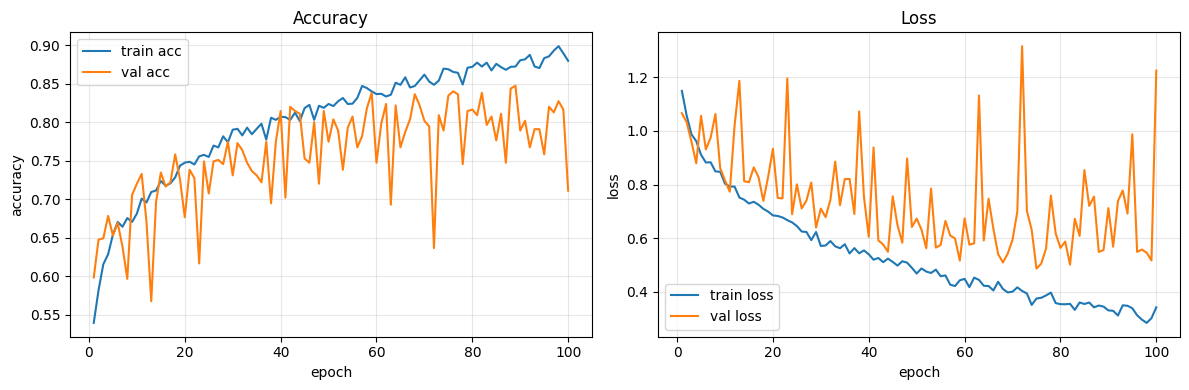

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 6. 在测试集上评估

使用训练过程中“验证集表现最好”的模型权重，在测试集上计算最终准确率。

In [8]:
criterion = nn.CrossEntropyLoss()
test_stats = evaluate(model, test_loader, criterion)
print(f"test loss: {test_stats.loss:.4f}")
print(f"test acc : {test_stats.acc:.4f}")

test loss: 0.4434
test acc : 0.8548


## 7. 预测效果可视化

从测试集随机取一些图片，展示：

- **真实标签（GT）**
- **预测标签（Pred）**
- **预测置信度（Softmax 概率）**

并用颜色区分预测对/错。

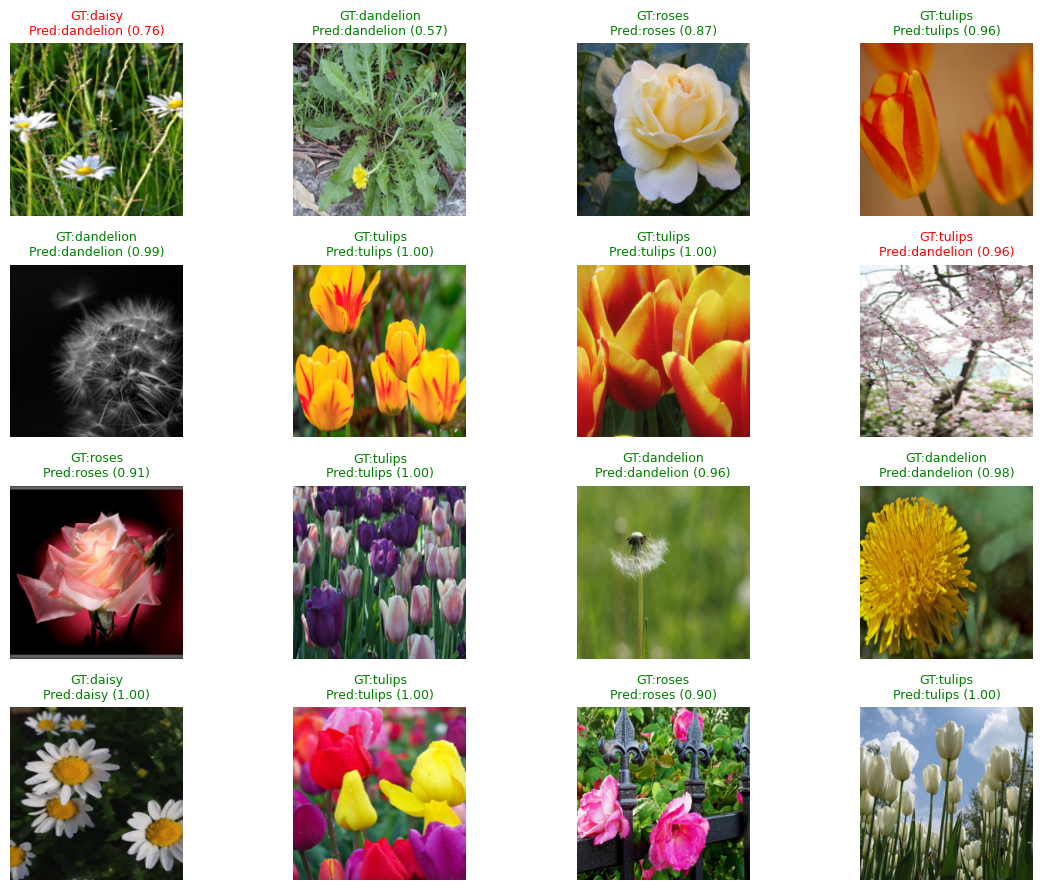

In [9]:
import torch.nn.functional as F

@torch.no_grad()
def collect_predictions(model, loader, max_items=32):
    model.eval()
    xs, ys, ps, confs = [], [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob = F.softmax(logits, dim=1)
        conf, pred = prob.max(dim=1)

        xs.append(x.cpu())
        ys.append(y.cpu())
        ps.append(pred.cpu())
        confs.append(conf.cpu())

        if sum(t.size(0) for t in xs) >= max_items:
            break

    x_all = torch.cat(xs, dim=0)[:max_items]
    y_all = torch.cat(ys, dim=0)[:max_items]
    p_all = torch.cat(ps, dim=0)[:max_items]
    c_all = torch.cat(confs, dim=0)[:max_items]
    return x_all, y_all, p_all, c_all

x_vis, y_vis, p_vis, c_vis = collect_predictions(model, test_loader, max_items=16)

plt.figure(figsize=(12, 9))
for i in range(len(x_vis)):
    plt.subplot(4, 4, i + 1)
    img = denormalize(x_vis[i])
    plt.imshow(img.permute(1, 2, 0))

    gt = class_names[int(y_vis[i])]
    pr = class_names[int(p_vis[i])]
    ok = int(y_vis[i]) == int(p_vis[i])

    title = f"GT:{gt}\nPred:{pr} ({float(c_vis[i]):.2f})"
    plt.title(title, fontsize=9, color=("green" if ok else "red"))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8.（可选）保存模型

把训练好的模型权重保存到本地，方便后续推理或继续训练。

In [10]:
SAVE_PATH = Path("class5/simple_cnn_flower_0.85.pth")
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "img_size": IMG_SIZE,
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD,
    },
    str(SAVE_PATH),
)
print("saved to:", SAVE_PATH.resolve())

saved to: D:\Codes\CV_Lib\class5\class5\simple_cnn_flower_0.85.pth
